1. PROJECT TITLE - AERIAL OBJECT CLASSIFICATION AND DETECTION

2. PROJECT SUMMARY - 

    This project presents an end-to-end deep learning solution for aerial image understanding by integrating both image classification and object detection techniques. Three modeling approaches were explored including a custom Convolutional Neural Network (CNN), a Transfer Learning model based on a pre-trained architecture (MobileNetV2) and a YOLOv8-based object detection model.

    The workflow involves data preprocessing, model training, evaluation and comparative analysis to determine the most effective approach. While the CNN and Transfer Learning models focus on classifying images into predefined categories, the YOLO model not classifies objects but also locates objects within images using bounding boxes.

    Performance evaluation was conducted using metrics such as accuracy, loss trends, confusion matrices and mean Average Precision (mAP) for object detection. Based on these evaluations, the YOLO model demonstrates superior real-world applicability due to its ability to both detect and classify objects.

    The final solution is deployed through an interactive Streamlit application, allowing users to upload images and visualize predictions across all three models, thereby providing a comprehensive and user-friendly interface for aerial object analysis.

3. PROBLEM STATEMENT - 

    This project aims to develop a deep learning-based solution that can classify aerial images into two categories — Bird or Drone — and optionally perform object detection to locate and label these objects in real-world scenes.
    
    The solution will help in security surveillance, wildlife protection, and airspace safety where accurate identification between drones and birds is critical. The project involves building a Custom CNN classification model, leveraging transfer learning, and optionally implementing YOLOv8 for real-time object detection. The final solution will be deployed using Streamlit for interactive use.

4. DATA WRANGLING -

In [1]:
# Importing the necessary libraries
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# Setting up the base path
base_dir = os.path.join('..', 'data', 'classification_dataset')

# Setting up the paths for train, valid and test data
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'valid')
test_dir = os.path.join(base_dir, 'test')

# Setting up the parameters
batch_size = 16
img_size = (224,224)

In [3]:
# Data Augmentation for training
train_datagen_cnn = ImageDataGenerator(rescale=1.0/255.0,
                                    rotation_range=20,
                                    horizontal_flip=True,
                                    zoom_range=0.2,
                                    brightness_range=[0.8,1.2])

# Validation and test data (no augmentation)
test_datagen_cnn = ImageDataGenerator(rescale=1.0/255.0)

# Creating training data generator
train_gen_cnn = train_datagen_cnn.flow_from_directory(train_dir,
                                                      target_size=img_size,
                                                      batch_size=batch_size,
                                                      class_mode='binary')

# Creating validation data generator
valid_gen_cnn = test_datagen_cnn.flow_from_directory(valid_dir,
                                                    target_size=img_size,
                                                    batch_size=batch_size,
                                                    class_mode='binary')

# Creating test data generator
test_gen_cnn = test_datagen_cnn.flow_from_directory(test_dir,
                                                    target_size=img_size,
                                                    batch_size=batch_size,
                                                    class_mode='binary',
                                                    shuffle=False)
# Printing the class indices
print("Class Indices:", train_gen_cnn.class_indices)

# Verifying batch shape
x_batch, y_batch = next(train_gen_cnn)
print('Batch shape:', x_batch.shape, y_batch.shape)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
Class Indices: {'bird': 0, 'drone': 1}
Batch shape: (16, 224, 224, 3) (16,)


In [4]:
# Importing the necessary libraries for building and training the CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
# Building CNN model
cnn = Sequential([Input(shape=(224, 224, 3)),

    # Three convolutional layers with batch normalization and max pooling was used to extract the features
    # Rectified Linear Unit (ReLU) activation function was used to introduce non-linearity
    # Sigmoid activation function was used in the output layer for binary classification
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),       # Flatten layer was used to convert 3D features to 1D feature vector

    Dense(128, activation='relu'),
    Dropout(0.5),    # Dropout layer was used to prevent overfitting 

    Dense(1, activation='sigmoid')])

In [6]:
# Compiling the model for binary classification
cnn.compile(optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [ ]:
# Callback to stop training early if validation loss stops improving
early_stop = EarlyStopping(monitor='val_loss',
    patience=5,
    restore_best_weights=True)

# Callback to save the best model during training
checkpoint = ModelCheckpoint(filepath='../models/cnn_model_final.h5',
    monitor='val_loss',
    save_best_only=True)

In [ ]:
# Defining steps per epoch for consistent training
steps_per_epoch = len(train_gen_cnn)
validation_steps = len(valid_gen_cnn)

In [9]:
# Training the model
history = cnn.fit(train_gen_cnn,
    validation_data=valid_gen_cnn,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=10,
    callbacks=[early_stop, checkpoint])

Epoch 1/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6441 - loss: 8.9590

167/167 ━━━━━━━━━━━━━━━━━━━━ 887s 5s/step - accuracy: 0.6446 - loss: 5.6631 - val_accuracy: 0.5068 - val_loss: 2.7609
Epoch 2/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6744 - loss: 1.0188

167/167 ━━━━━━━━━━━━━━━━━━━━ 1007s 6s/step - accuracy: 0.6630 - loss: 0.9749 - val_accuracy: 0.6810 - val_loss: 0.6778
Epoch 3/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 1157s 7s/step - accuracy: 0.6773 - loss: 0.6544 - val_accuracy: 0.6765 - val_loss: 0.7343
Epoch 4/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 1231s 7s/step - accuracy: 0.6593 - loss: 0.8649 - val_accuracy: 0.6900 - val_loss: 2.7549
Epoch 5/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 1182s 7s/step - accuracy: 0.6878 - loss: 0.5791 - val_accuracy: 0.7014 - val_loss: 0.9918
Epoch 6/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6794 - loss: 0.5562

167/167 ━━━━━━━━━━━━━━━━━━━━ 1163s 7s/step - accuracy: 0.6946 - loss: 0.5472 - val_accuracy: 0.7738 - val_loss: 0.4848
Epoch 7/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7135 - loss: 0.5265

167/167 ━━━━━━━━━━━━━━━━━━━━ 1219s 7s/step - accuracy: 0.7115 - loss: 0.5283 - val_accuracy: 0.7941 - val_loss: 0.4569
Epoch 8/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 1162s 7s/step - accuracy: 0.7288 - loss: 0.4967 - val_accuracy: 0.7602 - val_loss: 0.4578
Epoch 9/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 1153s 7s/step - accuracy: 0.7213 - loss: 0.5294 - val_accuracy: 0.6923 - val_loss: 0.5512
Epoch 10/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 1096s 7s/step - accuracy: 0.7303 - loss: 0.5341 - val_accuracy: 0.7941 - val_loss: 0.5230


In [ ]:
# Prediction on test data
y_pred_prob = cnn.predict(test_gen_cnn)
y_pred = (y_pred_prob > 0.5).astype(int)

14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step


In [11]:
# Evaluating model performance on test data
test_loss, test_acc = cnn.evaluate(test_gen_cnn)
print(f"Test Accuracy: {test_acc:.4f}")

# True labels
y_true = test_gen_cnn.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Classification Report
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=['birds', 'drones']))

14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8326 - loss: 0.4105
Test Accuracy: 0.8326
Classification Report:
              precision    recall  f1-score   support

       birds       0.83      0.88      0.86       121
      drones       0.84      0.77      0.80        94

    accuracy                           0.83       215
   macro avg       0.83      0.83      0.83       215
weighted avg       0.83      0.83      0.83       215



In [12]:
# Setting seaborn style for better visuals
sns.set(style="whitegrid")

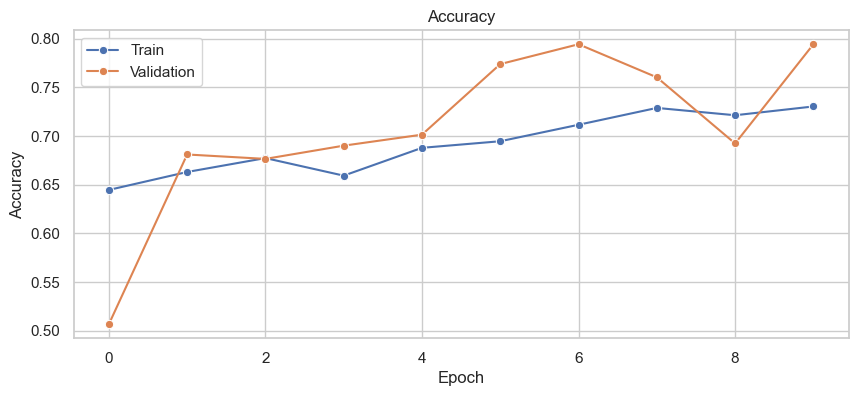

In [21]:
# Plotting training vs validation accuracy
plt.figure(figsize=(10,4))
sns.lineplot(x=range(len(history.history['accuracy'])), y=history.history['accuracy'], label='Train', marker='o')
sns.lineplot(x=range(len(history.history['val_accuracy'])), y=history.history['val_accuracy'], label='Validation', marker='o')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

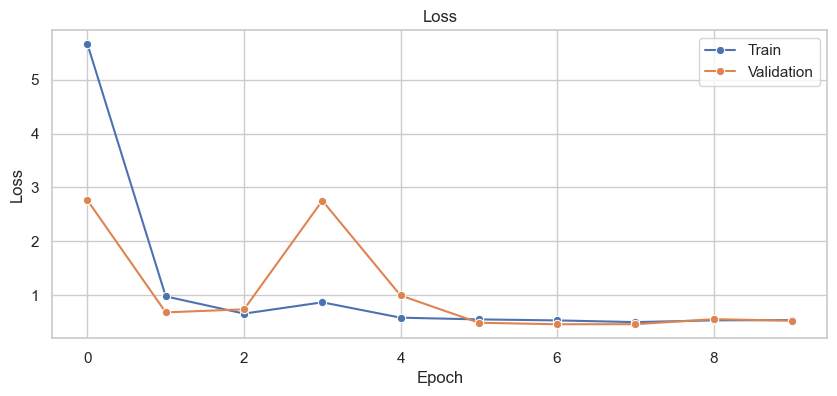

In [22]:
# Plotting training vs validation loss
plt.figure(figsize=(10,4))
sns.lineplot(x=range(len(history.history['loss'])), y=history.history['loss'], label='Train', marker='o')
sns.lineplot(x=range(len(history.history['val_loss'])), y=history.history['val_loss'], label='Validation', marker='o')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

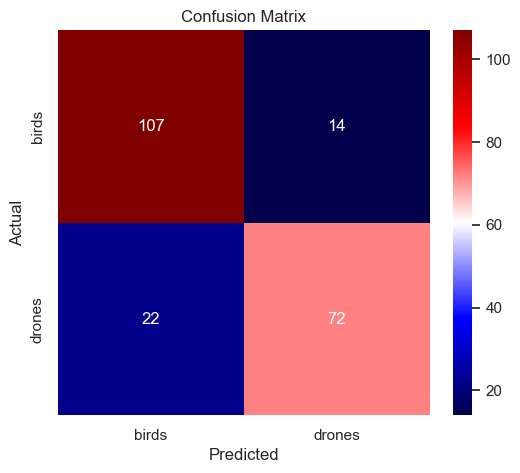

In [18]:
# Plotting the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='seismic', xticklabels=['birds', 'drones'], yticklabels=['birds', 'drones'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()